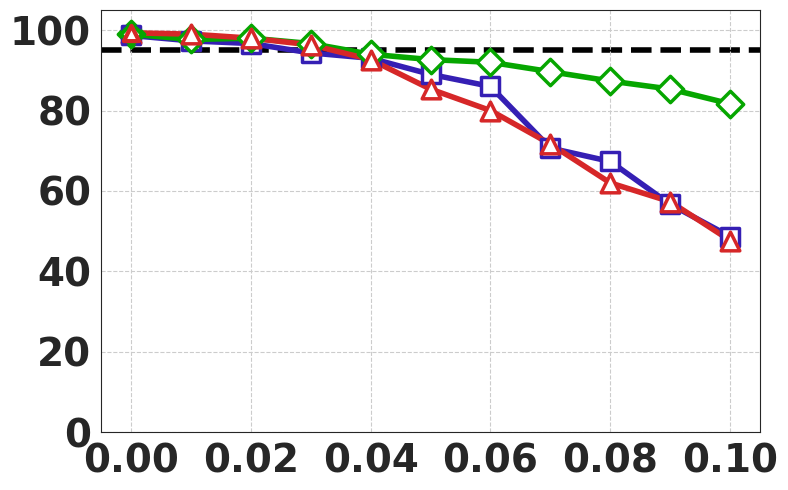

In [11]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# --- 描画設定 ---
custom_colors = {
    "ncp_u64_best":  "#351fb4",
    "u64":      "#351fb4",
    "ncp_u128_best": "#06a600",
    "u128":     "#06a600",
    "ncp_u256_best": "#d62728",
    "u256":     "#d62728",
}
markers = {
    "ncp_u64_best":  "s",
    "u64":      "s",
    "ncp_u128_best": "D",
    "u128":     "D",
    "ncp_u256_best": "^",
    "u256":     "^",
}
plot_order = ["ncp_u64_best","u64", "ncp_u128_best", "u128", "ncp_u256_best", "u256"]

# パラメータ
units = [64, 128, 256]
gaussians = np.arange(0.0, 0.11, 0.01).round(2).tolist()
base_path = "/work/robomimic/csv/eval/lift/error/gaussian"

results = []
for unit in units:
    for g in gaussians:
        pattern = f"{base_path}/unit{unit}/gaussian{g}.csv"
        files = sorted(glob.glob(pattern))
        if not files:
            continue
        df_all = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
        if "seed" in df_all.columns:
            group_col = "seed"
        else:
            df_all["seed"] = df_all["name"].str.extract(r"seed(\d+)").astype(float)
            group_col = "seed"
        # seedごとに最大success_rateを抽出
        df_max = df_all.loc[df_all.groupby(group_col)["success_rate"].idxmax()]
        # 成績上位3つのseedを選び平均化
        top3 = df_max.nlargest(3, "success_rate")
        mean_success = top3["success_rate"].mean()
        results.append({"unit": unit, "gaussian": g, "mean_success": mean_success})

import seaborn as sns
sns.set_style("white")
results_df = pd.DataFrame(results)
plt.figure(figsize=(8,5))
for unit, color, marker in zip(units, [custom_colors["u64"], custom_colors["u128"], custom_colors["u256"]], [markers["u64"], markers["u128"], markers["u256"]]):
    df_u = results_df[results_df["unit"] == unit]
    # 0.0のときだけ図形を左軸の上に描画
    if 0.0 in df_u["gaussian"].values:
        y0 = df_u[df_u["gaussian"] == 0.0]["mean_success"].values[0]
        plt.scatter([0.0], [y0*100], marker=marker, s=120, facecolors="white", edgecolors=color, linewidths=3, zorder=3)
    plt.plot(df_u["gaussian"], df_u["mean_success"]*100, color=color, linewidth=4, zorder=1)
    plt.scatter(df_u["gaussian"], df_u["mean_success"]*100, marker=marker, s=180, facecolors="white", edgecolors=color, linewidths=2.5, zorder=2)
plt.ylim(0, 105)
plt.xticks(np.arange(0.0, 0.11, 0.02), fontsize=28, fontweight="bold")
plt.yticks(np.arange(0, 101, 20), fontsize=28, fontweight="bold")
plt.xlabel("")
plt.ylabel("")
plt.axhline(95, color="black", linestyle="--", linewidth=4, zorder=0)
import matplotlib.ticker as ticker
ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MaxNLocator(6))
plt.grid(True, linestyle="--")
plt.tight_layout()
plt.show()


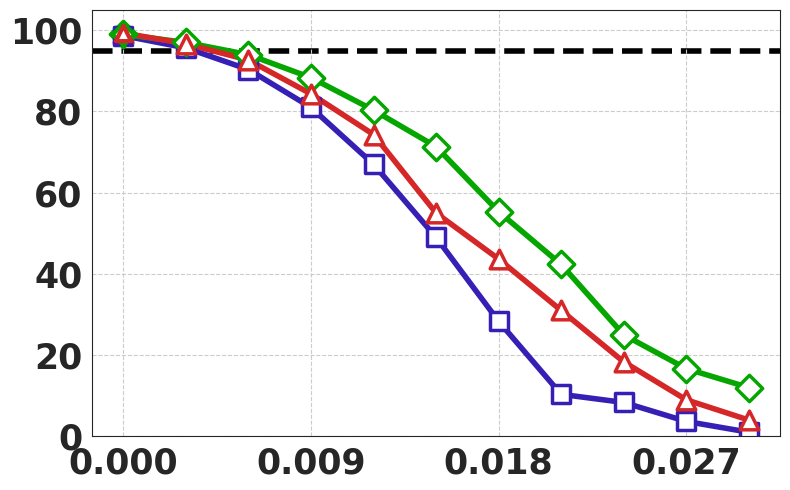

In [ ]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import matplotlib.ticker as ticker
import seaborn as sns

# --- 描画設定 ---
custom_colors = {
    "u64":  "#351fb4",
    "u128": "#06a600",
    "u256": "#d62728",
}
markers = {
    "u64":  "s",
    "u128": "D",
    "u256": "^",
}

# パラメータ
units = [64, 128, 256]
shifts = np.arange(0.0, 0.031, 0.003).round(3).tolist()
base_path = "/work/robomimic/csv/eval/lift/error/shift"

results = []
for unit in units:
    for s in shifts:
        pattern = f"{base_path}/unit{unit}/shift{s}.csv"
        files = sorted(glob.glob(pattern))
        if not files:
            continue

        df_all = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

        if "seed" in df_all.columns:
            group_col = "seed"
        else:
            df_all["seed"] = df_all["name"].str.extract(r"seed(\d+)").astype(int)
            group_col = "seed"

        # seed ごとの最大 success_rate
        df_max = df_all.loc[df_all.groupby(group_col)["success_rate"].idxmax()]

        # 上位3 seed の平均
        top3 = df_max.nlargest(3, "success_rate")
        mean_success = top3["success_rate"].mean()

        results.append({
            "unit": unit,
            "shift": s,
            "mean_success": mean_success
        })

sns.set_style("white")
results_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(8, 5))

for unit, color, marker in zip(
    units,
    [custom_colors["u64"], custom_colors["u128"], custom_colors["u256"]],
    [markers["u64"], markers["u128"], markers["u256"]]
):
    df_u = results_df[results_df["unit"] == unit]

    # shift値が0.0の点だけ少し右にずらして重なりを防ぐ
    x_shift = df_u["shift"].values.copy()
    if 0.0 in x_shift:
        idx0 = np.where(x_shift == 0.0)[0][0]
        x_shift[idx0] += 0.0008  # 0.0の点を少し右にずらす

    ax.plot(
        x_shift, df_u["mean_success"].values * 100,
        color=color, linewidth=4, zorder=1
)
    ax.scatter(
        x_shift, df_u["mean_success"].values * 100,
        marker=marker, s=180,
        facecolors="white", edgecolors=color,
        linewidths=2.5, zorder=2
)

ax.set_ylim(0, 105)
ax.set_xlim(-0.001, 0.031)
ax.set_xticks(np.arange(0.0, 0.031, 0.006))
ax.set_xticklabels([f"{x:.3f}".rstrip('0').rstrip('.') if x != 0.0 and x != 0.03 else str(int(x*1000)/1000) for x in np.arange(0.0, 0.031, 0.006)], fontsize=25, fontweight="bold")
ax.set_yticks(np.arange(0, 101, 20))
ax.set_yticklabels([str(y) for y in np.arange(0, 101, 20)], fontsize=25, fontweight="bold")

ax.set_xlabel("")
ax.set_ylabel("")
ax.axhline(95, color="black", linestyle="--", linewidth=4, zorder=0)

# --- 数字の重なりを防ぐためにpadを調整 ---
ax.tick_params(axis='x', pad=12)
ax.tick_params(axis='y', pad=12)

# --- 0.03ごとにグリッド線を引く ---
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.03))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.003))
ax.grid(which="major", axis="x", linestyle="--", alpha=0.7)
ax.grid(which="minor", axis="x", linestyle="--", alpha=0.3)
ax.grid(which="major", axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()
